In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [20]:
df = pd.read_csv("//Users/zofiabrodewicz/Documents/GitHub/Bachelor/collaborations_with_distances.csv")
df["log_avg_streams"] = np.log10(df["avg_streams"])

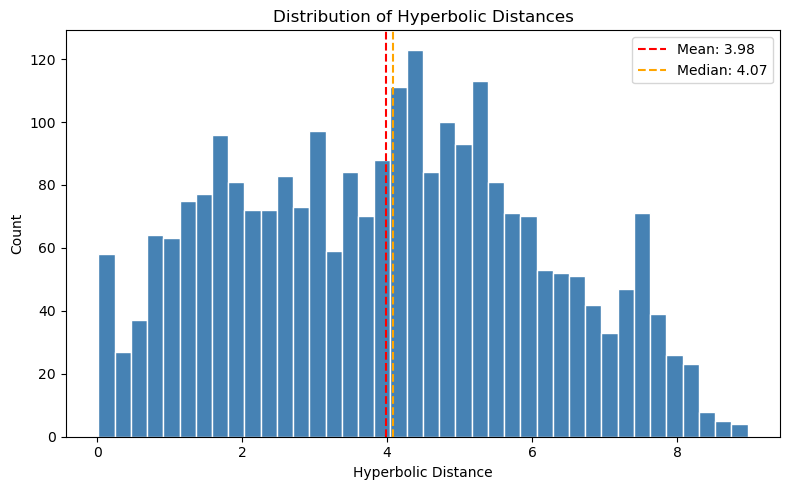

In [17]:
#  Plot 1: Distribution of distances 
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["hyperbolic_distance"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(df["hyperbolic_distance"].mean(), color="red", linestyle="--",
           label=f'Mean: {df["hyperbolic_distance"].mean():.2f}')
ax.axvline(df["hyperbolic_distance"].median(), color="orange", linestyle="--",
           label=f'Median: {df["hyperbolic_distance"].median():.2f}')
ax.set_title("Distribution of Hyperbolic Distances")
ax.set_xlabel("Hyperbolic Distance")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()



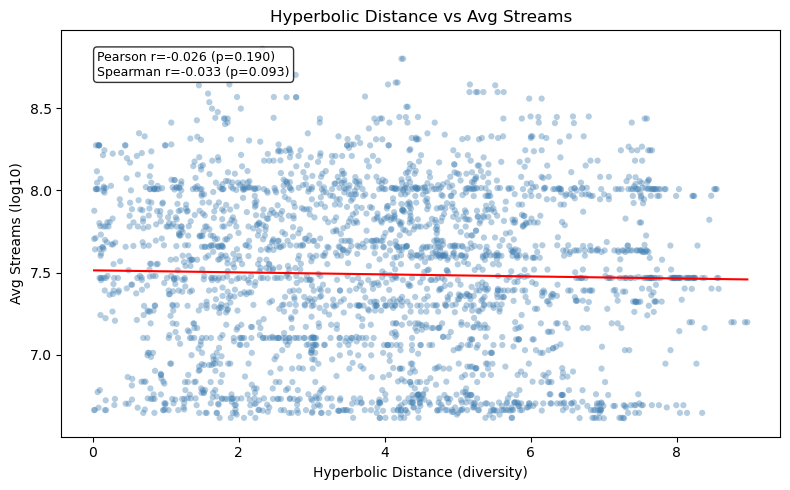

In [21]:
# Plot 2: Distance vs avg_streams 
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["hyperbolic_distance"], df["log_avg_streams"],
           alpha=0.4, color="steelblue", edgecolors="none", s=20)
z = np.polyfit(df["hyperbolic_distance"], df["log_avg_streams"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["hyperbolic_distance"].min(), df["hyperbolic_distance"].max(), 100)
ax.plot(x_line, p(x_line), color="red", linewidth=1.5)
pearson_r, pearson_p = stats.pearsonr(df["hyperbolic_distance"], df["log_avg_streams"])
spearman_r, spearman_p = stats.spearmanr(df["hyperbolic_distance"], df["log_avg_streams"])
ax.set_title("Hyperbolic Distance vs Avg Streams")
ax.set_xlabel("Hyperbolic Distance (diversity)")
ax.set_ylabel("Avg Streams (log10)")
ax.text(0.05, 0.95,
        f"Pearson r={pearson_r:.3f} (p={pearson_p:.3f})\nSpearman r={spearman_r:.3f} (p={spearman_p:.3f})",
        transform=ax.transAxes, fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()


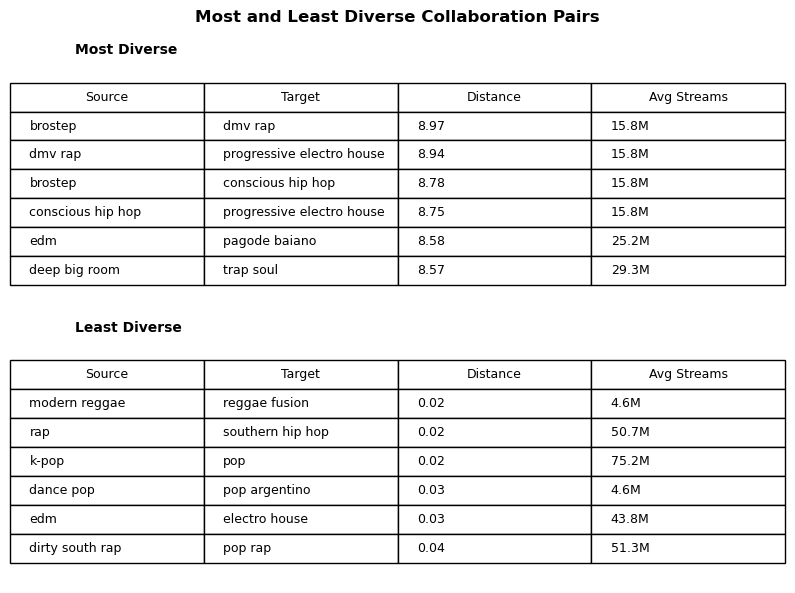

In [ ]:
# Plot 4: Most and least diverse pairs table
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
fig.suptitle("Most and Least Diverse Collaboration Pairs",
             fontsize=12, fontweight="bold")
top_diverse = df.nlargest(6, "hyperbolic_distance")[["source", "target", "hyperbolic_distance", "avg_streams"]]
top_similar = df.nsmallest(6, "hyperbolic_distance")[["source", "target", "hyperbolic_distance", "avg_streams"]]
diverse_data = [[row["source"], row["target"],
                 f'{row["hyperbolic_distance"]:.2f}',
                 f'{row["avg_streams"]/1e6:.1f}M']
                for _, row in top_diverse.iterrows()]
similar_data = [[row["source"], row["target"],
                 f'{row["hyperbolic_distance"]:.2f}',
                 f'{row["avg_streams"]/1e6:.1f}M']
                for _, row in top_similar.iterrows()]
for ax, data, title in zip(axes,
                            [diverse_data, similar_data],
                            ["Most Diverse", "Least Diverse"]):
    ax.axis("off")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")
    table = ax.table(cellText=data,
                     colLabels=["Source", "Target", "Distance", "Avg Streams"],
                     loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
plt.tight_layout()
plt.show()